In [3]:
##### Creates maps of agricultural capital and labor intensities 
# Side-by-side of pixel intensities and country intensities 

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer
import matplotlib.patches as mpatches
from matplotlib.colors import to_hex, Normalize
from matplotlib import cm

In [4]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# pixel data
capital_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/capital_intensity_USD_per_tonne.tif")
labor_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/labor_intensity_jobs_per_tonne.tif")

# sub-national data 
sub_national_capital = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_capital_intensity.csv")
sub_national_labor = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_labor_intensity.csv")
sub_national_capital_geo = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_capital.shp")
sub_national_labor_geo = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_labor.shp")

# national data
country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_boundaries = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/map_intensity_side_by_side"

In [5]:
### Data prep

# align rasters to capital grid
crs = capital_intensity.rio.crs

labor_intensity = labor_intensity.rio.reproject_match(capital_intensity)
country_boundaries = country_boundaries.to_crs(capital_intensity.rio.crs)
sub_national_capital_geo = sub_national_capital_geo.to_crs(capital_intensity.rio.crs)
sub_national_labor_geo = sub_national_labor_geo.to_crs(capital_intensity.rio.crs)

# add geo to country / sub-national intensities 
country_boundaries = country_boundaries.merge(country_codes, left_on='GID_0', right_on='SHP_code', how='left')
country_boundaries = country_boundaries.merge(country_intensities, on='ISO3', how='left')

sub_national_capital = sub_national_capital_geo.merge(sub_national_capital, on='PROJ_ID', how='left')
sub_national_labor = sub_national_labor_geo.merge(sub_national_labor, on='PROJ_ID', how='left')

#### Map intensity rasters

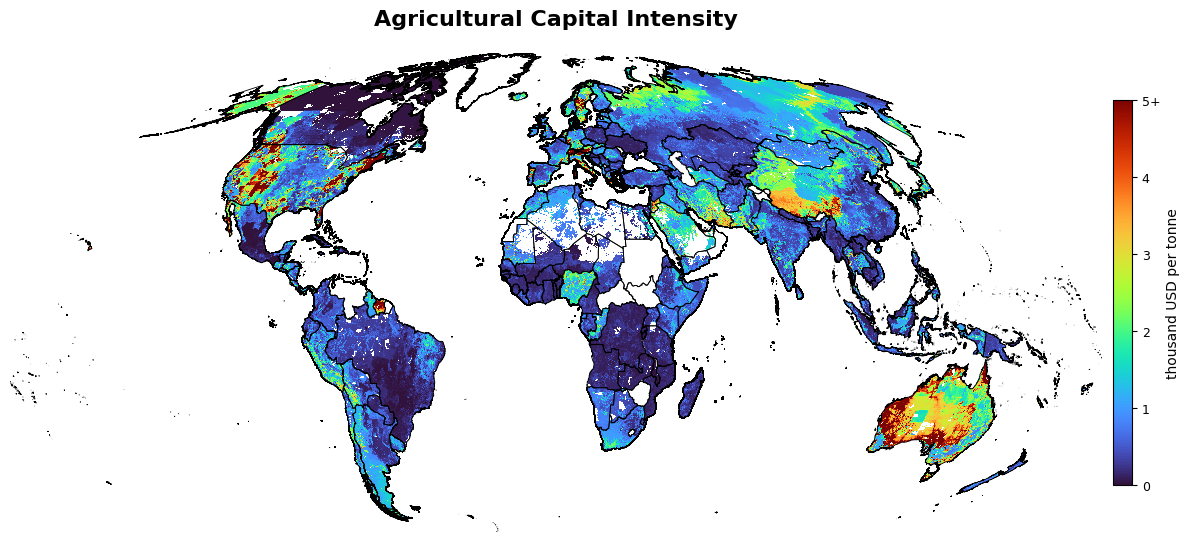

In [6]:
##### Produce global map of capital intensity

# Prepare raster
value_plot = capital_intensity.squeeze()
name = 'capital_intensity'

bounds = [0, 1000, 2000, 3000, 4000, 5000] 
labels = ['0', '1', '2', '3', '4', '5+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=5000,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Capital Intensity", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("thousand USD per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

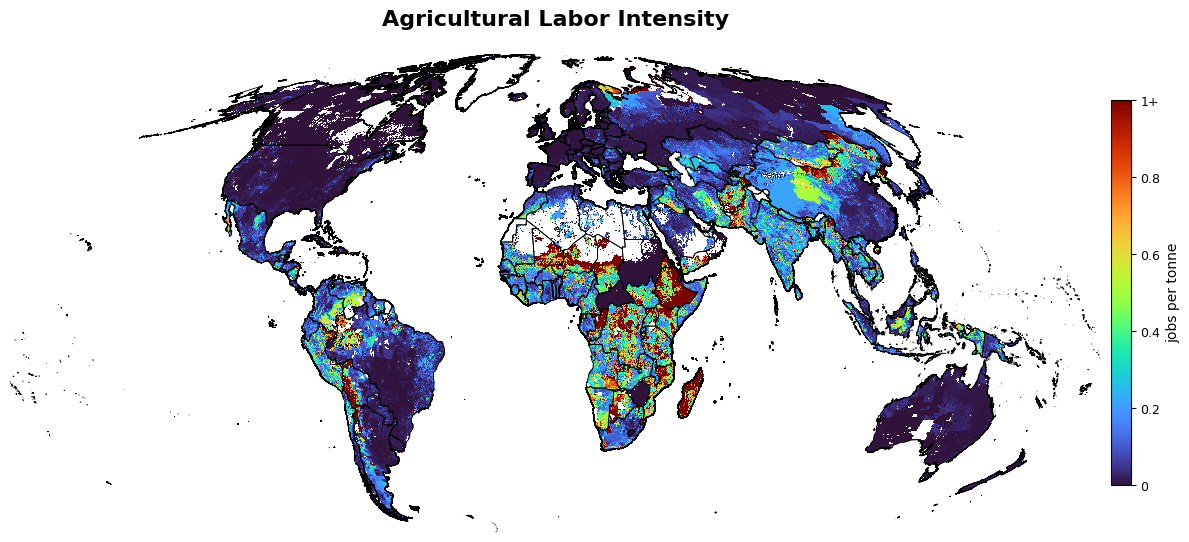

In [5]:
##### Produce global map of labor intensity

# Prepare raster
value_plot = labor_intensity.squeeze()
name = 'labor_intensity'

bounds = [0, 0.2, 0.4, 0.6, 0.8, 1] 
labels = ['0', '0.2', '0.4', '0.6', '0.8', '1+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=1,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Labor Intensity", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("jobs per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

#### Map intensities (country/raster side-by-side)

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_67393/406354452.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


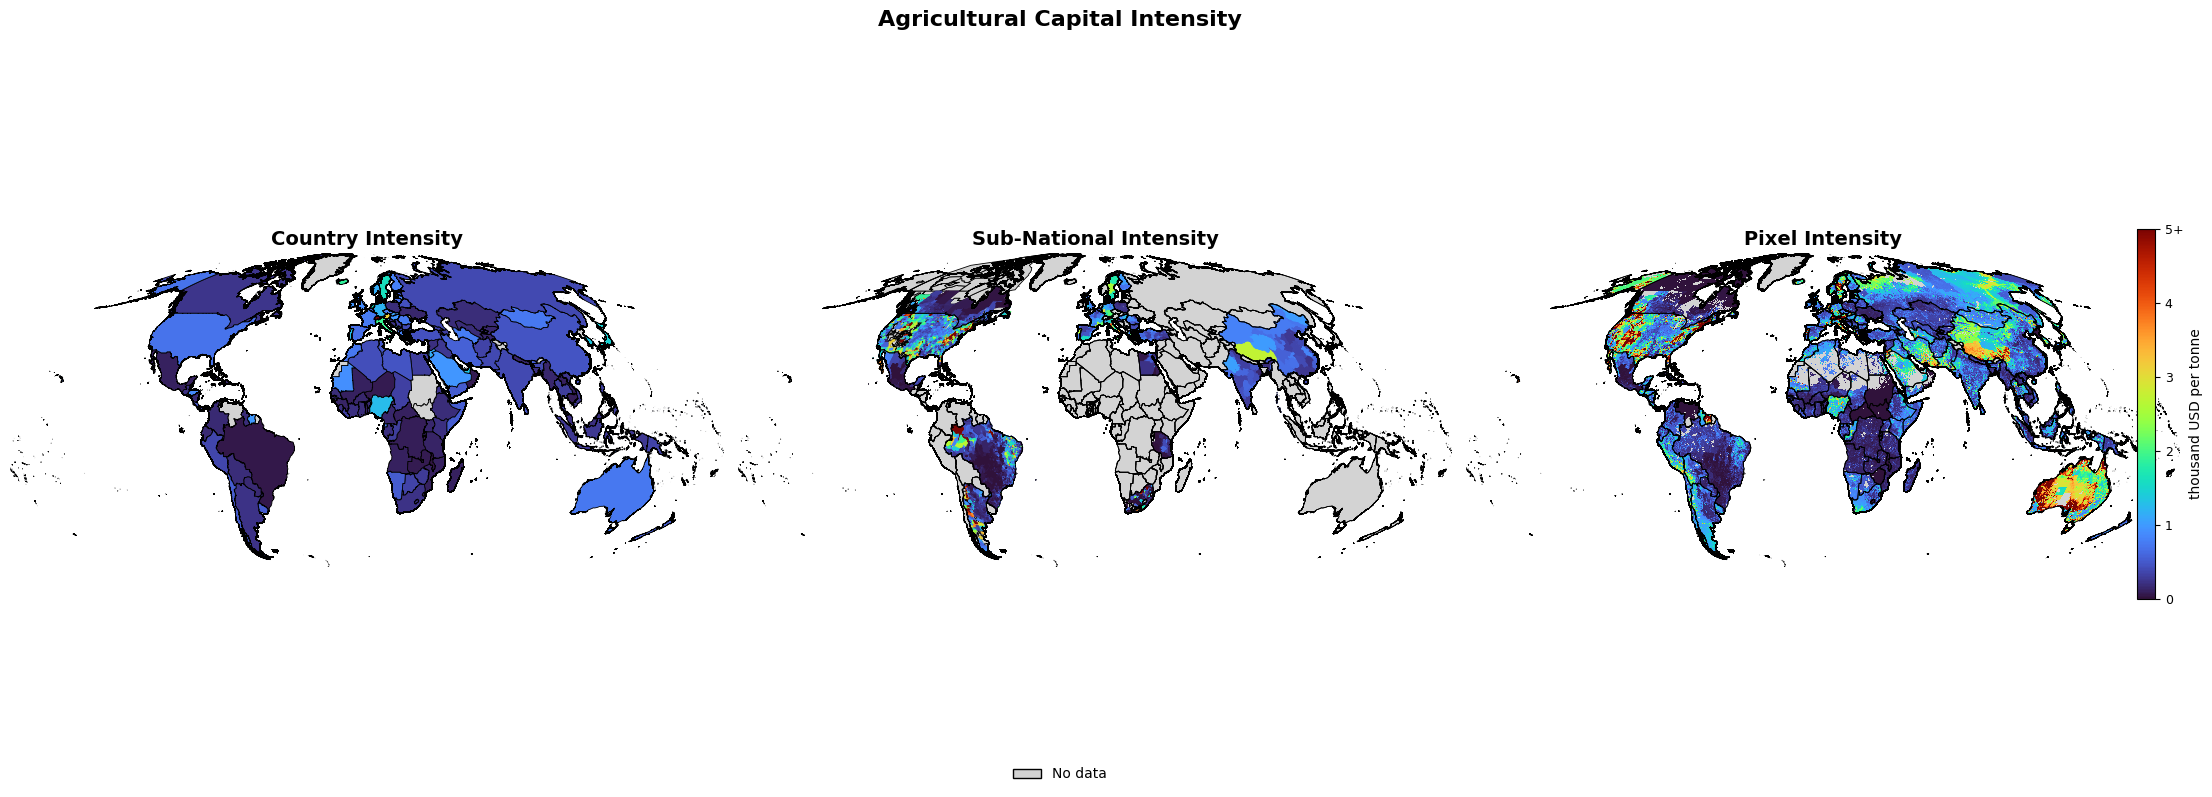

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_67393/406354452.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


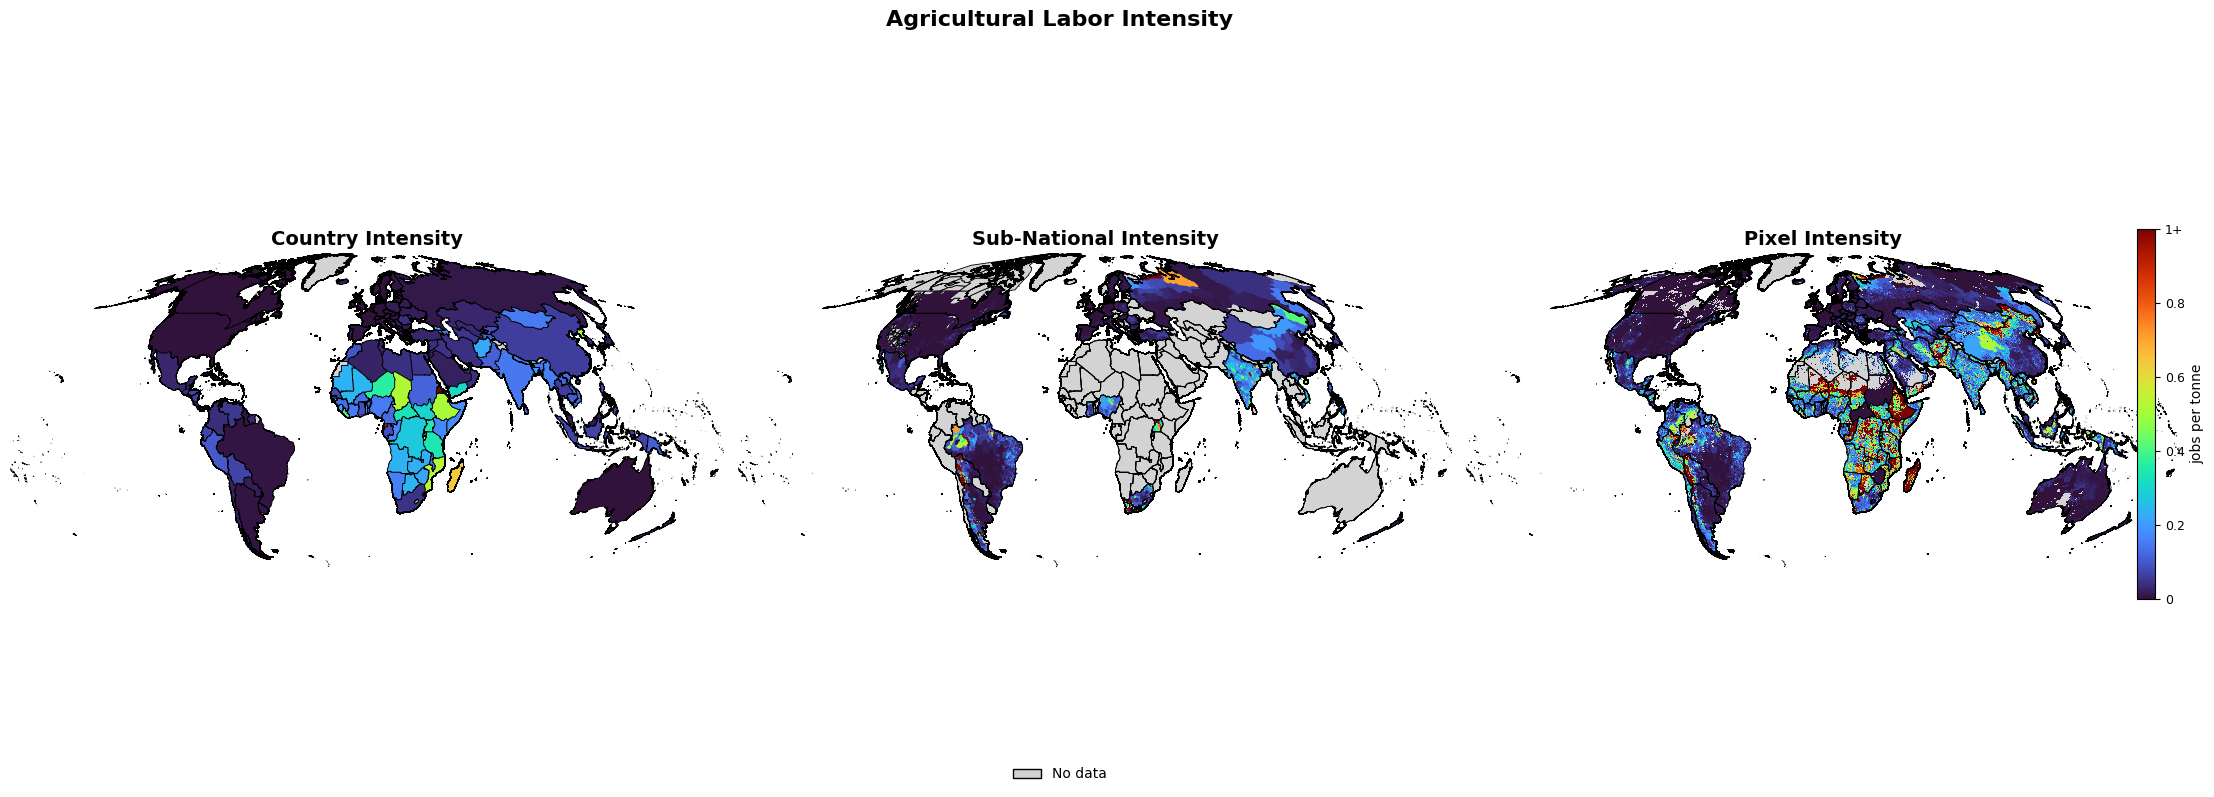

In [6]:
def plot_intensity_side_by_side(
    raster, country_gdf, sub_national_gdf, value_col, bounds, labels, vmin, vmax,
    title, cbar_label, out_path, cmap="turbo", missing_color="lightgrey"
):
    """
    Plot country-level choropleth intensity (left), sub-national choropleth
    intensity (middle), and pixel-level raster intensity (right), all on the
    same color scale. Areas/countries with missing data are shown in light
    grey on every panel, with a single shared colorbar and a 'No data' legend entry.
    """
    value_plot = raster.squeeze()

    fig, axes = plt.subplots(1, 3, figsize=(28, 8))
    minx, miny, maxx, maxy = country_gdf.total_bounds

    # --- Panel 1: country-level choropleth ---
    ax0 = axes[0]

    has_data = country_gdf[country_gdf[value_col].notna()]
    no_data = country_gdf[country_gdf[value_col].isna()]

    no_data.plot(ax=ax0, facecolor=missing_color, edgecolor="black", linewidth=0.6, zorder=1)
    has_data.plot(
        ax=ax0, column=value_col, cmap=cmap, vmin=vmin, vmax=vmax,
        edgecolor="black", linewidth=0.6, zorder=2
    )

    ax0.set_xlim(minx, maxx)
    ax0.set_ylim(miny, maxy)
    ax0.set_axis_off()
    ax0.set_title("Country Intensity", fontsize=14, weight="bold")

    # --- Panel 2: sub-national choropleth ---
    ax1 = axes[1]

    sub_has_data = sub_national_gdf[sub_national_gdf[value_col].notna()]
    sub_no_data = sub_national_gdf[sub_national_gdf[value_col].isna()]

    # grey country basemap first, so areas with no sub-national coverage show through
    country_gdf.plot(ax=ax1, facecolor=missing_color, edgecolor="black", linewidth=0.6, zorder=1)

    sub_no_data.plot(ax=ax1, facecolor=missing_color, edgecolor="black", linewidth=0.6, zorder=1)

    norm = Normalize(vmin=vmin, vmax=vmax)
    colormap = cm.get_cmap(cmap)
    colors = [to_hex(colormap(norm(v))) for v in sub_has_data[value_col]]

    sub_has_data.plot(
        ax=ax1,
        color=colors,
        edgecolor=colors,
        linewidth=0.6,
        zorder=2,
    )

    country_gdf.plot(ax=ax1, facecolor="none", edgecolor="black", linewidth=0.6, zorder=3)

    ax1.set_xlim(minx, maxx)
    ax1.set_ylim(miny, maxy)
    ax1.set_axis_off()
    ax1.set_title("Sub-National Intensity", fontsize=14, weight="bold")

    # --- Panel 3: pixel intensity ---
    ax2 = axes[2]

    country_gdf.plot(ax=ax2, facecolor=missing_color, edgecolor="black", linewidth=0.6, zorder=1)

    im = value_plot.plot(
        ax=ax2, cmap=cmap, vmin=vmin, vmax=vmax,
        add_colorbar=False, add_labels=False, zorder=2
    )

    country_gdf.plot(ax=ax2, facecolor="none", edgecolor="black", linewidth=0.6, zorder=3)

    ax2.set_xlim(minx, maxx)
    ax2.set_ylim(miny, maxy)
    ax2.set_axis_off()
    ax2.set_title("Pixel Intensity", fontsize=14, weight="bold")

    fig.suptitle(title, fontsize=16, weight="bold", y=1.0)

    # --- Shared colorbar (built off the raster image, same vmin/vmax as choropleths) ---
    cbar = fig.colorbar(
        im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, shrink=0.6
    )
    cbar.set_label(cbar_label, fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    cbar.set_ticks(bounds)
    cbar.set_ticklabels(labels)

    # --- Missing-data legend entry ---
    missing_patch = mpatches.Patch(facecolor=missing_color, edgecolor="black", label="No data")
    fig.legend(handles=[missing_patch], loc="lower center", bbox_to_anchor=(0.5, 0.02), frameon=False)

    fig.subplots_adjust(top=0.92, bottom=0.08, wspace=0.02)
    fig.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.1)
    plt.show()


# --- Capital intensity ---
plot_intensity_side_by_side(
    raster=capital_intensity,
    country_gdf=country_boundaries,
    sub_national_gdf=sub_national_capital,
    value_col="capital_intensity_USD_per_tonne",
    bounds=[0, 1000, 2000, 3000, 4000, 5000],
    labels=['0', '1', '2', '3', '4', '5+'],
    vmin=0, vmax=5000,
    title="Agricultural Capital Intensity",
    cbar_label="thousand USD per tonne",
    out_path=f"{fd}/capital_intensity_side_by_side.png",
)

# --- Labor intensity ---
plot_intensity_side_by_side(
    raster=labor_intensity,
    country_gdf=country_boundaries,
    sub_national_gdf=sub_national_labor,
    value_col="labor_intensity_jobs_per_tonne",
    bounds=[0, 0.2, 0.4, 0.6, 0.8, 1],
    labels=['0', '0.2', '0.4', '0.6', '0.8', '1+'],
    vmin=0, vmax=1,
    title="Agricultural Labor Intensity",
    cbar_label="jobs per tonne",
    out_path=f"{fd}/labor_intensity_side_by_side.png",
)